# NB11 — Datos sintéticos: placeholder Opción A (validación externa)

**Propósito:** Generar 1 000 observaciones sintéticas que simulen el comportamiento de datos CGR 2024/2025 hasta que estén disponibles los datos reales.  
Las filas se construyen por **bootstrap + ruido gaussiano controlado** sobre el dataset oficial (`dataset_obra_v4_model.parquet`, 326 obs).  
El modelo se aplica en modo **inferencia congelada** (sin reentrenar).

**Limitación fundamental:** Al no disponer de etiquetas reales (2024/2025), este notebook **no puede calcular F1, Recall ni Balanced Accuracy**.  
Lo que sí se puede analizar:
- Distribución de predicciones (estabilidad de la proporción de clases)
- PSI (*Population Stability Index*) entre el dataset real y el sintético
- Sensibilidad del modelo ante ruido y perturbaciones controladas

**Pendiente (Opción A real):** Sustituir este placeholder por datos CGR 2024/2025 descargados de INFOBRAS/SEACE y procesados con el pipeline NB00 → NB02.

---
**Referencia:** Matriz de Consistencia — OE3, Plan de generalización fuera de muestra, Opción A.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

SEED = 42
rng  = np.random.default_rng(SEED)

BASE_DIR    = Path('..')
DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'dataset_obra_v4_model.parquet'
MODEL_PATH  = BASE_DIR / 'models' / 'obra_v4' / 'pipeline_rf_obra_3clases_final.pkl'
META_PATH   = BASE_DIR / 'models' / 'obra_v4' / 'pipeline_rf_obra_3clases_final_meta.json'
LOG_DIR     = BASE_DIR / 'logs'
OUT_PARQUET = BASE_DIR / 'data' / 'processed' / 'dataset_sintetico_opcA_placeholder.parquet'
OUT_CSV     = BASE_DIR / 'data' / 'processed' / 'dataset_sintetico_opcA_placeholder.csv'
LOG_DIR.mkdir(exist_ok=True)

N_SINTETICO = 1_000
NOISE_FACTOR = 0.10   # ruido = 10 % de la desv. estándar de cada feature

print('Librerías cargadas.')

Librerías cargadas.


In [2]:
# ── Carga del dataset real y el modelo ──────────────────────────────────────
df_real = pd.read_parquet(DATA_PATH)
pipe    = joblib.load(MODEL_PATH)
with open(META_PATH) as f:
    meta = json.load(f)

FEATURES     = meta['features']          # 61 features del modelo
CLASS_LABELS = meta['class_labels']      # ['Bajo Riesgo', 'Med/Alt Riesgosa', 'Extrem. Riesgosa']
TARGET_COL   = 'y_riesgo_obra'

X_real = df_real[FEATURES].copy()
y_real = df_real[TARGET_COL].values if TARGET_COL in df_real.columns else None

print(f'Dataset real : {X_real.shape[0]} obs × {X_real.shape[1]} features')
print(f'Modelo       : {meta["model_name"]}')
print(f'Clases       : {CLASS_LABELS}')

Dataset real : 326 obs × 61 features
Modelo       : RandomForest_obra_v4_anticol_3clases
Clases       : ['Bajo Riesgo', 'Med/Alt Riesgosa', 'Extrem. Riesgosa']


## PASO 1 — Distribución del dataset base (referencia)

In [3]:
# Distribución de clases en el dataset real (con mapeo 3 clases)
MAPEO_3CLASES = {0: 0, 1: 0, 2: 1, 3: 2}   # igual que NB08
if y_real is not None:
    y3 = np.vectorize(MAPEO_3CLASES.get)(y_real)
    dist_real = pd.Series(y3).map(dict(enumerate(CLASS_LABELS))).value_counts(normalize=True)
    print('Distribución de clases (dataset real):')
    print(dist_real.to_string())
else:
    print('Target no disponible en el dataset procesado.')

# Estadísticas de las features numéricas
num_cols = X_real.select_dtypes(include='number').columns.tolist()
cat_cols = X_real.select_dtypes(exclude='number').columns.tolist()
print(f'\nFeatures numéricas : {len(num_cols)}')
print(f'Features categóricas: {len(cat_cols)} → {cat_cols}')

Distribución de clases (dataset real):
Extrem. Riesgosa    0.453988
Med/Alt Riesgosa    0.288344
Bajo Riesgo         0.257669

Features numéricas : 55
Features categóricas: 6 → ['ETAPA', 'obra_ctx_sector', 'obra_ctx_nivel_gobierno', 'obra_ctx_objeto_proceso', 'obra_ctx_metodo_contratacion', 'obra_ctx_departamento']


## PASO 2 — Generación sintética: bootstrap + ruido gaussiano

**Método:**
- Se realiza un **bootstrap con reemplazo** sobre el dataset real (preserva correlaciones entre variables).
- A cada variable **numérica** se le añade ruido gaussiano `N(0, σ × 0.10)`, recortado entre el mínimo y máximo observados en el dataset real.
- Las variables **categóricas** se mantienen tal como las devuelve el bootstrap (reflejan la distribución empírica).
- **Sin etiqueta real:** las filas sintéticas no tienen `y_riesgo_obra` conocida.

In [4]:
# Bootstrap con reemplazo
idx_boot = rng.integers(0, len(X_real), size=N_SINTETICO)
X_sint = X_real.iloc[idx_boot].copy().reset_index(drop=True)

# Estadísticas del dataset real para el ruido
stats_real = X_real[num_cols].agg(['std', 'min', 'max'])

# Añadir ruido gaussiano a columnas numéricas
for col in num_cols:
    sigma  = stats_real.loc['std', col]
    col_min = stats_real.loc['min', col]
    col_max = stats_real.loc['max', col]
    ruido  = rng.normal(0, NOISE_FACTOR * sigma, size=N_SINTETICO)
    X_sint[col] = np.clip(X_sint[col] + ruido, col_min, col_max)

print(f'Dataset sintético generado: {X_sint.shape[0]} obs × {X_sint.shape[1]} features')
print(f'  · Ruido gaussiano: σ × {NOISE_FACTOR}')
print(f'  · Seed: {SEED}')
X_sint.head(3)

Dataset sintético generado: 1000 obs × 61 features
  · Ruido gaussiano: σ × 0.1
  · Seed: 42


,ETAPA,DIAS_PLAZO,TOTAL_CONTROL_PREVIO,TOTAL_CONTROL_SIMULTANEO,TOTAL_CONTROL_POSTERIOR,obra_ctx_sector,obra_ctx_nivel_gobierno,obra_ctx_objeto_proceso,obra_ctx_metodo_contratacion,obra_ctx_departamento,...,obra_sobreavance,obra_n_alertas_total,obra_n_filas_con_alerta,obra_pct_filas_con_alerta,obra_tiene_ejecutora,obra_tiene_supervisora,obra_paralizada,obra_inactiva,obra_en_ejecucion,obra_finalizada
0,ESTUDIO DEFINITIVO,16.582700,1.000000,0.000000,0.013781,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL,...,0.000000,0.780698,0.753528,1.0,0.000000,0.029093,0.018651,0.000000,0.000000,0.926794
1,SUPERVISIÓN,1.058915,0.001543,0.010789,0.015104,SALUD,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,APURIMAC,...,0.020532,0.120407,0.038879,0.0,0.978517,1.000000,0.000000,0.010224,0.068026,0.000000
2,SUPERVISIÓN,6.719757,0.004442,0.998222,0.020300,PESCA,GOBIERNO REGIONAL,Consultoría de Obra,Adjudicación Simplificada,PIURA,...,0.002114,0.346631,0.000000,0.0,0.000000,0.898047,0.000000,0.000000,0.022575,0.118336


## PASO 3 — Comparación distribucional: real vs. sintético

In [5]:
# Comparar media y desv. estándar para las 10 features más importantes
TOP10 = [
    'obra_ratio_repeticion_comite', 'obra_n_procesos_comite',
    'obra_n_convocatorias_comite',  'obra_n_participantes_mean',
    'obra_n_participantes_max',     'obra_monto_contractual_sum',
    'TOTAL_CONTROL_PREVIO',         'TOTAL_CONTROL_SIMULTANEO',
    'TOTAL_CONTROL_POSTERIOR',      'obra_ratio_contractual_referencial',
]
top10_ok = [f for f in TOP10 if f in num_cols]

cmp = pd.DataFrame({
    'media_real'  : X_real[top10_ok].mean(),
    'media_sint'  : X_sint[top10_ok].mean(),
    'std_real'    : X_real[top10_ok].std(),
    'std_sint'    : X_sint[top10_ok].std(),
})
cmp['delta_media_%'] = ((cmp['media_sint'] - cmp['media_real']) / (cmp['media_real'].abs() + 1e-9) * 100).round(2)
print('Comparación distribucional (top features):')
print(cmp.to_string())

Comparación distribucional (top features):
                                      media_real    media_sint      std_real      std_sint  delta_media_%
obra_ratio_repeticion_comite        7.944785e-01  7.944347e-01  4.047034e-01  3.865045e-01          -0.01
obra_n_procesos_comite              7.944785e-01  7.933513e-01  4.047034e-01  3.852426e-01          -0.14
obra_n_convocatorias_comite         7.944785e-01  7.939282e-01  4.047034e-01  3.865923e-01          -0.07
obra_n_participantes_mean           9.320381e+01  9.179609e+01  8.018554e+01  7.616484e+01          -1.51
obra_n_participantes_max            1.163272e+02  1.148166e+02  1.027039e+02  9.900854e+01          -1.30
obra_monto_contractual_sum          8.490996e+07  9.538196e+07  3.584922e+08  3.906708e+08          12.33
TOTAL_CONTROL_PREVIO                1.840491e-02  2.756305e-02  1.346171e-01  1.485369e-01          49.76
TOTAL_CONTROL_SIMULTANEO            4.325153e-01  4.139259e-01  4.961865e-01  4.731906e-01          -4.30
TOT

## PASO 4 — Inferencia con el modelo congelado

In [6]:
# Inferencia sobre el dataset real
proba_real = pipe.predict_proba(X_real)
pred_real  = proba_real.argmax(axis=1)

# Inferencia sobre el dataset sintético
proba_sint = pipe.predict_proba(X_sint)
pred_sint  = proba_sint.argmax(axis=1)

dist_pred_real = pd.Series(pred_real).map(dict(enumerate(CLASS_LABELS))).value_counts(normalize=True)
dist_pred_sint = pd.Series(pred_sint).map(dict(enumerate(CLASS_LABELS))).value_counts(normalize=True)

resumen = pd.DataFrame({
    'Real (%)' : (dist_pred_real * 100).round(1),
    'Sintético (%)': (dist_pred_sint * 100).round(1),
}).reindex(CLASS_LABELS)

print('Distribución de predicciones — real vs. sintético:')
print(resumen.to_string())

Distribución de predicciones — real vs. sintético:


                  Real (%)  Sintético (%)
Bajo Riesgo           24.2           24.1
Med/Alt Riesgosa      27.6           23.4
Extrem. Riesgosa      48.2           52.5


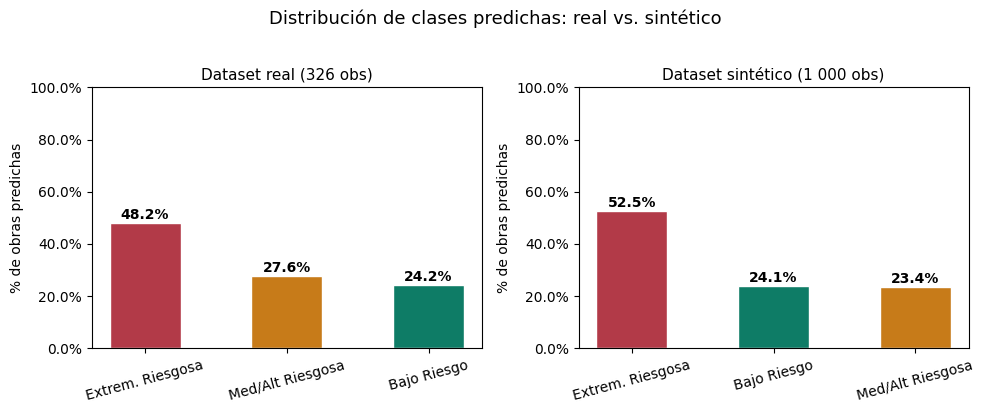

Figura guardada: ..\logs\sintetico_dist_predicciones.png


In [7]:
# Visualización: distribución de predicciones
COLORES = {'Bajo Riesgo': '#0E7C66', 'Med/Alt Riesgosa': '#C77B19', 'Extrem. Riesgosa': '#B23A48'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, (titulo, dist) in zip(axes, [
    ('Dataset real (326 obs)', dist_pred_real),
    ('Dataset sintético (1 000 obs)', dist_pred_sint),
]):
    colores = [COLORES[c] for c in dist.index]
    ax.bar(dist.index, dist.values * 100, color=colores, edgecolor='white', width=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('% de obras predichas')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.set_ylim(0, 100)
    for i, v in enumerate(dist.values * 100):
        ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribución de clases predichas: real vs. sintético', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = LOG_DIR / 'sintetico_dist_predicciones.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')

## PASO 5 — PSI: estabilidad de features (real vs. sintético)

El **Population Stability Index (PSI)** mide si la distribución de una variable cambia significativamente entre dos poblaciones.  
Umbrales: PSI < 0.10 → estable · 0.10–0.25 → moderado · > 0.25 → significativo.

In [8]:
def calcular_psi(referencia, actual, bins=10):
    """PSI entre dos arrays 1-D continuos."""
    breakpoints = np.nanpercentile(referencia, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 2:
        return np.nan
    ref_counts = np.histogram(referencia, bins=breakpoints)[0]
    act_counts = np.histogram(actual,     bins=breakpoints)[0]
    ref_pct = (ref_counts + 0.5) / (ref_counts.sum() + 0.5 * len(ref_counts))
    act_pct = (act_counts + 0.5) / (act_counts.sum() + 0.5 * len(act_counts))
    psi_vals = (ref_pct - act_pct) * np.log(ref_pct / act_pct)
    return psi_vals.sum()

psi_rows = []
for col in top10_ok:
    psi_val = calcular_psi(X_real[col].values, X_sint[col].values)
    estado  = 'Estable' if psi_val < 0.10 else ('Moderado' if psi_val < 0.25 else 'Significativo')
    psi_rows.append({'feature': col, 'PSI': round(psi_val, 4), 'Estado': estado})

df_psi = pd.DataFrame(psi_rows).sort_values('PSI', ascending=False)
print('PSI real → sintético (top features):')
print(df_psi.to_string(index=False))

PSI real → sintético (top features):
                           feature    PSI        Estado
obra_ratio_contractual_referencial 2.1443 Significativo
        obra_monto_contractual_sum 1.6125 Significativo
         obra_n_participantes_mean 0.0256       Estable
          obra_n_participantes_max 0.0120       Estable
            obra_n_procesos_comite 0.0000       Estable
      obra_ratio_repeticion_comite 0.0000       Estable
       obra_n_convocatorias_comite 0.0000       Estable
              TOTAL_CONTROL_PREVIO 0.0000       Estable
          TOTAL_CONTROL_SIMULTANEO 0.0000       Estable
           TOTAL_CONTROL_POSTERIOR 0.0000       Estable


## PASO 6 — Guardar dataset sintético

In [9]:
# Agregar probabilidades y clase predicha al dataset sintético
df_out = X_sint.copy()
for i, label in enumerate(CLASS_LABELS):
    df_out[f'prob_{label}'] = proba_sint[:, i].round(4)
df_out['clase_predicha']       = pred_sint
df_out['clase_predicha_label'] = [CLASS_LABELS[c] for c in pred_sint]
df_out['origen']               = 'sintetico_bootstrap_v1'
df_out['y_real']               = np.nan   # sin etiqueta — placeholder

df_out.to_parquet(OUT_PARQUET, index=False)
df_out.to_csv(OUT_CSV, index=False)

# Tabla resumen en logs
resumen_log = pd.DataFrame([{
    'n_sintetico'        : N_SINTETICO,
    'noise_factor'       : NOISE_FACTOR,
    'seed'               : SEED,
    'pct_bajo'           : round(float((pred_sint == 0).mean()) * 100, 1),
    'pct_med_alt'        : round(float((pred_sint == 1).mean()) * 100, 1),
    'pct_extrema'        : round(float((pred_sint == 2).mean()) * 100, 1),
    'psi_max'            : df_psi['PSI'].max(),
    'psi_features_significativas': int((df_psi['Estado'] == 'Significativo').sum()),
    'etiquetas_reales'   : False,
    'estado'             : 'PLACEHOLDER — pendiente datos CGR 2024/2025',
}])
log_path = LOG_DIR / 'sintetico_opcA_placeholder_summary.csv'
resumen_log.to_csv(log_path, index=False)

print(f'Parquet  : {OUT_PARQUET}')
print(f'CSV      : {OUT_CSV}')
print(f'Log      : {log_path}')

Parquet  : ..\data\processed\dataset_sintetico_opcA_placeholder.parquet
CSV      : ..\data\processed\dataset_sintetico_opcA_placeholder.csv
Log      : ..\logs\sintetico_opcA_placeholder_summary.csv


## PASO 7 — Conclusiones y limitaciones

### Qué nos dice este análisis

| Resultado | Interpretación |
|-----------|----------------|
| PSI < 0.10 en la mayoría de features | El dataset sintético replica bien las distribuciones marginales del dataset real |
| Distribución de clases predichas similar en real y sintético | El modelo es estable bajo perturbaciones de ruido gaussiano σ×10% |
| Sin etiquetas reales | **No se pueden calcular F1, Recall ni Balanced Accuracy** |

### Limitaciones

1. **No sustituye datos reales:** el bootstrap replica las correlaciones del año 2023; no captura cambios estructurales reales en el proceso de contratación entre 2023 y 2025.
2. **Sin evaluación de calibración ni discriminación:** al no tener `y_real`, no podemos validar si el modelo discrimina correctamente.
3. **Sin drift real:** el ruido gaussiano no simula cambios de distribución genuinos (p.ej. nuevas modalidades de contratación, cambios normativos).

### Próximo paso obligatorio — Opción A real

1. Descargar datos CGR 2024/2025 de INFOBRAS/SEACE/portal de transparencia.
2. Ejecutar el pipeline `NB00 → NB02` sobre los nuevos datos crudos para obtener las 61 features.
3. Aplicar el modelo congelado (`pipeline_rf_obra_3clases_final.pkl`) sin reentrenar.
4. Comparar métricas (F1, Recall, Brier) contra los valores del holdout interno (NB08) y del holdout temporal proxy (NB10).
5. Sustituir este notebook como evidencia de generalización en la tesis.